In [5]:
# Import data and load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Define the path to the Excel file
file_path = r"C:\Users\shala\OneDrive\Desktop\Churn_Project\Prediction_Churn.xlsx"

# Define the sheet name to read the data
sheet_name = 'vw_ChurnData'

# Read the data from the specified sheet into pandas dataframe
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows from data
print(data.head())

  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   11814-GUJ  Female   45     Yes      Gujarat                   12   
1   11850-MAH    Male   74     Yes  Maharashtra                    5   
2   11873-HAR    Male   45     Yes      Haryana                    9   
3   11878-RAJ    Male   75     Yes    Rajasthan                   15   
4   11882-BIH  Female   74      No        Bihar                   14   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 9        NaN           Yes            Yes  ...   
1                 6        NaN           Yes            Yes  ...   
2                10     Deal 2           Yes             No  ...   
3                17        NaN           Yes             No  ...   
4                15     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal     105.550003   6281.450195           0.0   
1      Credit Card      75.1

In [6]:
# Data Processing
# Drop columns that wont be used for prediction
data = data.drop(
    columns=['Customer_ID', 'Churn_Category', 'Churn_Reason'],
    errors='ignore'
)

# List of the columns to be label encoded
column_to_encode = [
    'Gender','Married','State', 'Value_Deal','Phone_Service','Multiple_Lines',
    'Internet_Service', 'Internet_Type','Online_Security','Online_Backup',
    'Device_Protection_Plan','Premium_Support','Streaming_TV','Streaming_Movies',
    'Streaming_Music','Unlimited_Data','Contract','Paperless_Billing','Payment_Method']

# Encode categorical variables except the target variable
label_encoders = {}
for column in column_to_encode:
    label_encoders[column]=LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manualy encode the target variable 'Customer_Status'
data['Customer_Status']=data['Customer_Status'].map({'Stayed':0, 'Churned':1})

# Split data into features and target 
X = data.drop('Customer_Status',axis =1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, x_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 42)

In [7]:
# Train Random forest Model
# Initilize the random forest classifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

#Train The model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Confusion Matrix:
[[825  39]
 [118 220]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       864
           1       0.85      0.65      0.74       338

    accuracy                           0.87      1202
   macro avg       0.86      0.80      0.83      1202
weighted avg       0.87      0.87      0.86      1202



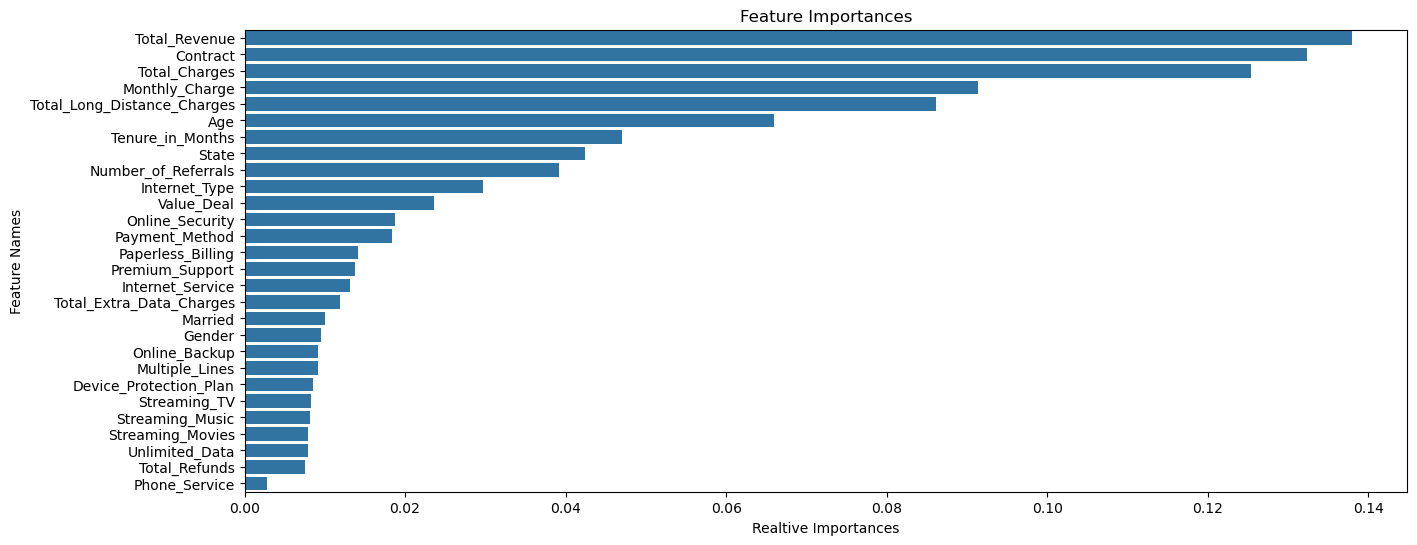

In [13]:
# Evaluate model
# Make predictions
y_pred = rf_model.predict(x_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature selection using feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importance
plt.figure(figsize= (15,6))
sns.barplot(x=importances[indices],y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Realtive Importances')
plt.ylabel('Feature Names')
plt.show()
           

In [17]:
# Predict on new data
# Define the path to the Joiner Data Excel file
file_path = "C:/Users/shala/OneDrive/Desktop/Churn_Project/Prediction_Churn.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'

# Read the data from specified sheet into a pandas Dataframe
new_data = pd.read_excel(file_path, sheet_name= sheet_name)

# Display th efirst few rows of fetched data
print(new_data.head())

# Retain the original Dataframe to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that wont be used for predition in the encoded Dataframe
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'] ,axis =1)

# Encode categorical variables using the saved label encoder
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Make Predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original dataframe
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the Dataframe to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the Results
original_data.to_excel(
    "C:/Users/shala/OneDrive/Desktop/Churn_Project/Prediction_Churn.xlsx",
    index=False
)

  Customer_ID  Gender  Age Married            State  Number_of_Referrals  \
0   13058-MAD  Female   58      No   Madhya Pradesh                   13   
1   13123-BIH  Female   46      No            Bihar                   13   
2   14567-TAM    Male   43      No       Tamil Nadu                    1   
3   27461-MAD    Male   22     Yes   Madhya Pradesh                    7   
4   27465-JAM  Female   50      No  Jammu & Kashmir                   10   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                22        NaN           Yes             No  ...   
1                18     Deal 5           Yes             No  ...   
2                 9        NaN           Yes             No  ...   
3                 6     Deal 5           Yes             No  ...   
4                30        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0     Mailed Check      46.099998    130.149994           0.0   
1  B

In [18]:
print(new_predictions)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0
 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1]
